# DATATHON 2026 — The Gridbreaker
## Notebook 01: Data Audit & Split

**Mục tiêu:** Hiểu cấu trúc dữ liệu, phát hiện bất thường, và tách tập Train/Validation trước khi phân tích sâu.

---

### Checklist Data Audit:
- Type & Cardinality
- Missing values & Duplicates
- PK/FK Integrity
- Data Leakage Check
- Target Distribution
- Time-based Split

---
## 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6), 'figure.dpi': 100, 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#44BBA4',
          '#E94F37', '#393E41', '#5C946E', '#6B4C9A', '#D4A574']
sns.set_palette(sns.color_palette(COLORS))

def fmt_num(n):
    if pd.isna(n): return 'N/A'
    if abs(n) >= 1e9: return f'{n/1e9:.1f}B'
    elif abs(n) >= 1e6: return f'{n/1e6:.1f}M'
    elif abs(n) >= 1e3: return f'{n/1e3:.1f}K'
    return f'{n:,.0f}'

print('Import thành công!')

Import thành công!


---
## 2. Load Data & Overview

In [2]:
DATA_DIR = '../dataset/'

products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv')
promotions = pd.read_csv(DATA_DIR + 'promotions.csv')
geography = pd.read_csv(DATA_DIR + 'geography.csv')
orders = pd.read_csv(DATA_DIR + 'orders.csv')
order_items = pd.read_csv(DATA_DIR + 'order_items.csv')
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv')
returns = pd.read_csv(DATA_DIR + 'returns.csv')
reviews = pd.read_csv(DATA_DIR + 'reviews.csv')
sales = pd.read_csv(DATA_DIR + 'sales.csv')
inventory = pd.read_csv(DATA_DIR + 'inventory.csv')
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')
sample_sub = pd.read_csv(DATA_DIR + 'sample_submission.csv')

# Parse dates
for df, cols in [(customers, ['signup_date']), (orders, ['order_date']),
                 (promotions, ['start_date','end_date']), (shipments, ['ship_date','delivery_date']),
                 (returns, ['return_date']), (reviews, ['review_date']),
                 (sales, ['Date']), (sample_sub, ['Date']),
                 (inventory, ['snapshot_date']), (web_traffic, ['date'])]:
    for c in cols:
        df[c] = pd.to_datetime(df[c])

datasets = {'products': products, 'customers': customers, 'promotions': promotions,
            'geography': geography, 'orders': orders, 'order_items': order_items,
            'payments': payments, 'shipments': shipments, 'returns': returns,
            'reviews': reviews, 'sales': sales, 'inventory': inventory, 'web_traffic': web_traffic}

print(f"{'Bảng':<20} {'Dòng':>10} {'Cột':>6} {'MB':>8}")
print("="*50)
for name, df in datasets.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"{name:<20} {df.shape[0]:>10,} {df.shape[1]:>6} {mem:>7.1f}")

Bảng                       Dòng    Cột       MB
products                  2,412      8     0.7
customers               121,930      7    29.0
promotions                   50     10     0.0
geography                39,948      4     6.9
orders                  646,945      8   162.8
order_items             714,669      7    78.0
payments                646,945      4    50.6
shipments               566,067      4    17.3
returns                  39,939      7     6.1
reviews                 113,551      7    17.8
sales                     3,833      3     0.1
inventory                60,247     17    16.8
web_traffic               3,652      7     0.4


---
## 3. Type & Cardinality Audit

Kiểm tra kiểu dữ liệu, số lượng giá trị duy nhất, và phần trăm missing cho mỗi cột.

In [3]:
def audit_table(name, df):
    """Tạo bảng audit chi tiết cho một DataFrame."""
    audit = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notnull().sum(),
        'null_count': df.isnull().sum(),
        'null_pct': (df.isnull().sum() / len(df) * 100).round(1),
        'nunique': df.nunique(),
        'sample_value': [df[c].dropna().iloc[0] if df[c].notnull().any() else 'N/A' for c in df.columns]
    })
    print(f"\n{'='*80}")
    print(f"{name.upper()} — {len(df):,} dòng × {len(df.columns)} cột")
    print(f"{'='*80}")
    display(audit)
    
    # Đánh dấu cardinality
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        print(f"\n  Categorical columns cardinality:")
        for c in cat_cols:
            nuniq = df[c].nunique()
            label = 'HIGH' if nuniq > 50 else ('MEDIUM' if nuniq > 10 else 'LOW')
            print(f"    {c:<30} {nuniq:>8} unique [{label}]")

for name, df in datasets.items():
    audit_table(name, df)


PRODUCTS — 2,412 dòng × 8 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
product_id,int64,2412,0,0.0,2412,536
product_name,object,2412,0,0.0,2172,SaigonFlex UC-01
category,object,2412,0,0.0,4,Streetwear
segment,object,2412,0,0.0,8,Everyday
size,object,2412,0,0.0,4,S
color,object,2412,0,0.0,10,green
price,float64,2412,0,0.0,1990,11059.65
cogs,float64,2412,0,0.0,2381,9704.842875



  Categorical columns cardinality:
    product_name                       2172 unique [HIGH]
    category                              4 unique [LOW]
    segment                               8 unique [LOW]
    size                                  4 unique [LOW]
    color                                10 unique [LOW]

CUSTOMERS — 121,930 dòng × 7 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
customer_id,int64,121930,0,0.0,121930,1
zip,int64,121930,0,0.0,31491,15201
city,object,121930,0,0.0,42,Hai Phong
signup_date,datetime64[ns],121930,0,0.0,3941,2021-12-30 00:00:00
gender,object,121930,0,0.0,3,Female
age_group,object,121930,0,0.0,5,35-44
acquisition_channel,object,121930,0,0.0,6,social_media



  Categorical columns cardinality:
    city                                 42 unique [MEDIUM]
    gender                                3 unique [LOW]
    age_group                             5 unique [LOW]
    acquisition_channel                   6 unique [LOW]

PROMOTIONS — 50 dòng × 10 cột


...


INVENTORY — 60,247 dòng × 17 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
snapshot_date,datetime64[ns],60247,0,0.0,126,2022-10-31 00:00:00
product_id,int64,60247,0,0.0,1624,1
stock_on_hand,int64,60247,0,0.0,1895,3
units_received,int64,60247,0,0.0,360,1
units_sold,int64,60247,0,0.0,303,1
stockout_days,int64,60247,0,0.0,29,2
days_of_supply,float64,60247,0,0.0,9289,90.0
fill_rate,float64,60247,0,0.0,29,0.9333
stockout_flag,int64,60247,0,0.0,2,1
overstock_flag,int64,60247,0,0.0,2,0



  Categorical columns cardinality:
    product_name                       1465 unique [HIGH]
    category                              4 unique [LOW]
    segment                               8 unique [LOW]

WEB_TRAFFIC — 3,652 dòng × 7 cột


,dtype,non_null,null_count,null_pct,nunique,sample_value
date,datetime64[ns],3652,0,0.0,3652,2013-01-01 00:00:00
sessions,int64,3652,0,0.0,3447,9760
unique_visitors,int64,3652,0,0.0,3382,7253
page_views,int64,3652,0,0.0,3620,39093
bounce_rate,float64,3652,0,0.0,261,0.00514
avg_session_duration_sec,float64,3652,0,0.0,1771,102.9
traffic_source,object,3652,0,0.0,6,organic_search



  Categorical columns cardinality:
    traffic_source                        6 unique [LOW]


---
## 4. Missing Values Analysis

GIÁ TRỊ THIẾU (MISSING VALUES)

  promotions:
     applicable_category             40 (80.00%)

  order_items:
     promo_id                   438,353 (61.34%)
     promo_id_2                 714,463 (99.97%)


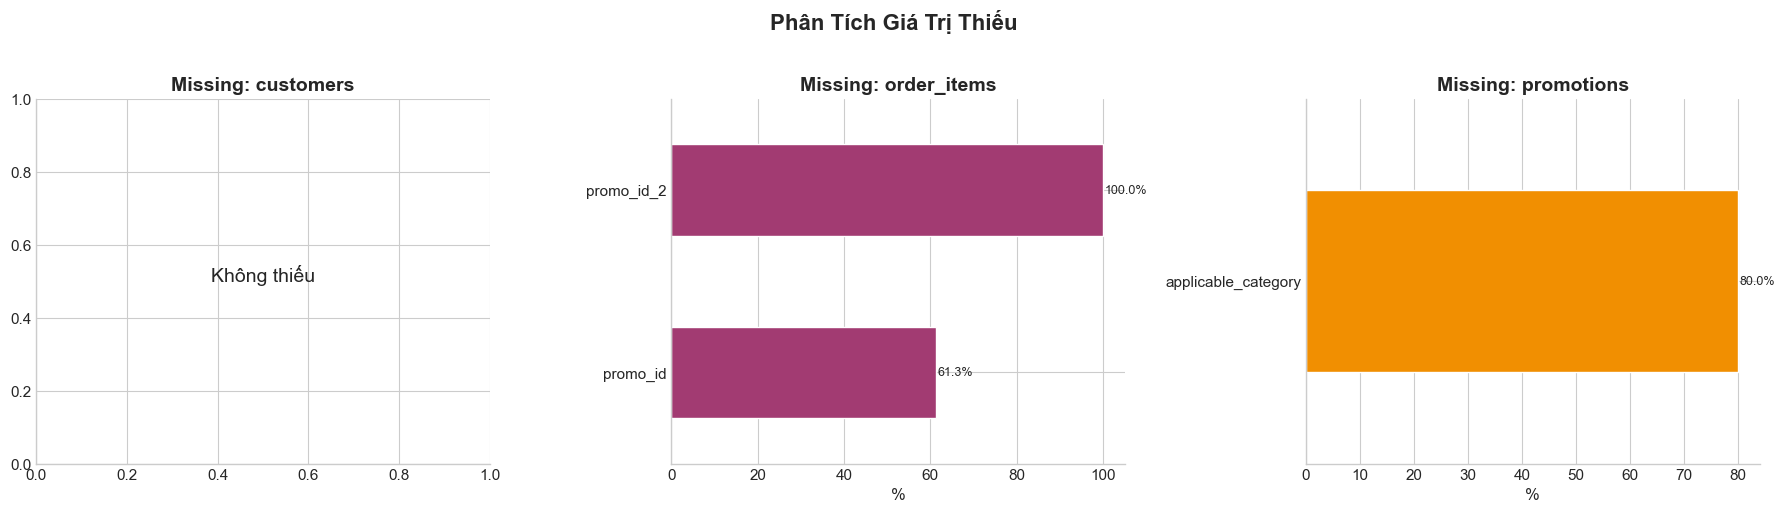

In [4]:
print("GIÁ TRỊ THIẾU (MISSING VALUES)")
print("="*55)
for name, df in datasets.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f"\n  {name}:")
        for col, cnt in miss.items():
            print(f"     {col:<25} {cnt:>8,} ({cnt/len(df)*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, df) in enumerate([('customers', customers), ('order_items', order_items), ('promotions', promotions)]):
    miss_pct = (df.isnull().sum() / len(df) * 100).sort_values()
    miss_pct = miss_pct[miss_pct > 0]
    if len(miss_pct) > 0:
        miss_pct.plot(kind='barh', ax=axes[idx], color=COLORS[idx], edgecolor='white')
        axes[idx].set_title(f'Missing: {name}', fontweight='bold')
        axes[idx].set_xlabel('%')
        for i, v in enumerate(miss_pct):
            axes[idx].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
    else:
        axes[idx].text(0.5, 0.5, 'Không thiếu', transform=axes[idx].transAxes, ha='center', fontsize=14)
        axes[idx].set_title(f'Missing: {name}', fontweight='bold')
plt.suptitle('Phân Tích Giá Trị Thiếu', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Kết luận Missing Values

- **Descriptive:** Missing tập trung ở demographics (`gender`, `age_group`) và promo fields (`promo_id`, `promo_id_2`, `applicable_category`)
- **Diagnostic:** Các trường nullable này do thiết kế nghiệp vụ — thu thập không bắt buộc (demographics) hoặc đơn hàng không áp dụng khuyến mãi (promo fields). `promo_id_2` gần 100% null → khả năng cao là trường dự phòng chưa dùng.
- **Prescriptive:** Dùng `'Unknown'` cho demographics thay vì drop rows.

---
## 5. Duplicate & PK/FK Integrity Check

In [5]:
# 5.1 Primary Key Uniqueness
print("KIỂM TRA KHÓA CHÍNH (PRIMARY KEY)")
print("="*55)
for name, pk, df in [('products','product_id',products), ('customers','customer_id',customers),
                      ('orders','order_id',orders), ('payments','order_id',payments),
                      ('geography','zip',geography), ('returns','return_id',returns),
                      ('reviews','review_id',reviews)]:
    dups = len(df) - df[pk].nunique()
    print(f"{name}.{pk}: {len(df):,} rows, {dups} duplicates")

print(f"\nKIỂM TRA KHÓA NGOẠI (FOREIGN KEY)")
print("="*55)
for fk_n, fk_v, pk_n, pk_v in [
    ('orders.customer_id', orders['customer_id'], 'customers.customer_id', customers['customer_id']),
    ('order_items.order_id', order_items['order_id'], 'orders.order_id', orders['order_id']),
    ('order_items.product_id', order_items['product_id'], 'products.product_id', products['product_id']),
    ('payments.order_id', payments['order_id'], 'orders.order_id', orders['order_id']),
    ('returns.order_id', returns['order_id'], 'orders.order_id', orders['order_id']),
    ('reviews.order_id', reviews['order_id'], 'orders.order_id', orders['order_id'])]:
    orphans = fk_v[~fk_v.isin(pk_v)].nunique()
    print(f" {fk_n} → {pk_n} | orphans: {orphans}")

KIỂM TRA KHÓA CHÍNH (PRIMARY KEY)
products.product_id: 2,412 rows, 0 duplicates
customers.customer_id: 121,930 rows, 0 duplicates
orders.order_id: 646,945 rows, 0 duplicates
payments.order_id: 646,945 rows, 0 duplicates
geography.zip: 39,948 rows, 0 duplicates
returns.return_id: 39,939 rows, 0 duplicates
reviews.review_id: 113,551 rows, 0 duplicates

KIỂM TRA KHÓA NGOẠI (FOREIGN KEY)
 orders.customer_id → customers.customer_id | orphans: 0
 order_items.order_id → orders.order_id | orphans: 0
 order_items.product_id → products.product_id | orphans: 0
 payments.order_id → orders.order_id | orphans: 0
 returns.order_id → orders.order_id | orphans: 0
 reviews.order_id → orders.order_id | orphans: 0


In [6]:
# 5.2 Full Duplicate Rows Check
print("\nKIỂM TRA DÒNG TRÙNG LẶP HOÀN TOÀN")
print("="*55)
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    status = f'{dup_count} dòng trùng'
    print(f"  {name:<20} {status}")


KIỂM TRA DÒNG TRÙNG LẶP HOÀN TOÀN
  products             0 dòng trùng
  customers            0 dòng trùng
  promotions           0 dòng trùng
  geography            0 dòng trùng
  orders               0 dòng trùng
  order_items          0 dòng trùng
  payments             0 dòng trùng
  shipments            0 dòng trùng
  returns              0 dòng trùng
  reviews              0 dòng trùng
  sales                0 dòng trùng
  inventory            0 dòng trùng
  web_traffic          0 dòng trùng


### Kết luận PK/FK & Duplicates

- **Descriptive:** Tất cả Primary Keys đều unique (không trùng). Tất cả Foreign Keys đều hợp lệ (không có orphan records).
- **Diagnostic:** Dữ liệu đã được thiết kế tốt, đảm bảo referential integrity hoàn chỉnh.
- **Prescriptive:** Có thể join các bảng một cách an toàn mà không lo mất dữ liệu.

---
## 6. Advanced Business Rule & Anomaly Validation (Kiểm tra Ngoại lệ Hệ thống)

Phần này phân tích các lỗ hổng hệ thống trầm trọng liên quan đến quá trình vận hành, dòng tiền và tracking dữ liệu. Các lỗi này không chỉ là vấn đề data chất lượng kém, mà còn là các báo động đỏ cho đội ngũ Business.

In [7]:
# Load bổ sung bảng returns và shipments nếu chưa có
import pandas as pd
import os
DATA_DIR = '../dataset/'
if 'returns' not in locals():
    returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date'])
if 'shipments' not in locals():
    shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date'])
    
# 6.1. Nghịch lý Xuyên không (Time-Travel Paradox)
print("=== 6.1. Nghịch lý Xuyên không (Customers vs Orders) ===")
cust_orders = orders.merge(customers[['customer_id', 'signup_date']], on='customer_id', how='inner')
time_travel = cust_orders[cust_orders['order_date'] < cust_orders['signup_date']]
print(f"Số lượng đơn hàng xảy ra TRƯỚC ngày tạo tài khoản: {len(time_travel):,} ({len(time_travel)/len(orders):.1%})")
print("=> LỖI KIẾN TRÚC DỮ LIỆU: Hệ thống cho phép Guest Checkout hoặc lỗi chuyển đổi dữ liệu. Cần lấy min(order_date) làm signup_date thực tế.\n")

# 6.2. Lỗ hổng Hoàn tiền (Cancelled & Refund Loopholes)
print("=== 6.2. Lỗ hổng Hoàn tiền (Orders vs Payments vs Returns) ===")
cancelled_orders = orders[orders['order_status'] == 'cancelled']
paid_cancelled = cancelled_orders.merge(payments, on='order_id', how='inner')
unrefunded = paid_cancelled[~paid_cancelled['order_id'].isin(returns['order_id'])]
print(f"Số đơn Hủy đã thu tiền nhưng KHÔNG CÓ BẢN GHI HOÀN TIỀN: {len(unrefunded):,}")

returned_orders = orders[orders['order_status'] == 'returned']
ghost_returns = returned_orders[~returned_orders['order_id'].isin(returns['order_id'])]
print(f"Số đơn trạng thái Returned nhưng 'bốc hơi' khỏi bảng returns: {len(ghost_returns):,}")
print("=> BÁO ĐỘNG ĐỎ TÀI CHÍNH: Doanh nghiệp có thể đang dính rủi ro kiện cáo hoặc thất thoát quỹ ngoài hệ thống.\n")

# 6.3. Vận đơn Ma (Fake Deliveries)
print("=== 6.3. Vận đơn Ma (Orders vs Shipments) ===")
delivered_orders = orders[orders['order_status'].isin(['shipped', 'delivered'])]
ghost_deliveries = delivered_orders[~delivered_orders['order_id'].isin(shipments['order_id'])]
print(f"Số đơn hàng Shipped/Delivered nhưng KHÔNG CÓ DỮ LIỆU VẬN ĐƠN: {len(ghost_deliveries):,}")
print("=> LỖ HỔNG VẬN HÀNH: Gian lận kho bãi (Fake Delivery) hoặc lỗi API kết nối làm rớt dữ liệu vận chuyển.\n")

# 6.4. Rác Giỏ hàng (Cart Aggregation Bug)
print("=== 6.4. Rác Giỏ hàng (Order_items) ===")
cart_dupes = order_items.groupby(['order_id', 'product_id']).size().reset_index(name='count')
bug_count = len(cart_dupes[cart_dupes['count'] > 1])
print(f"Số trường hợp 1 đơn hàng tách cùng 1 sản phẩm ra nhiều dòng thay vì cộng dồn số lượng: {bug_count:,}")
print("=> LỖI FRONT-END LOGIC: Ảnh hưởng đến dữ liệu chạy mô hình Market Basket Analysis.")


=== 6.1. Nghịch lý Xuyên không (Customers vs Orders) ===
Số lượng đơn hàng xảy ra TRƯỚC ngày tạo tài khoản: 477,453 (73.8%)
=> LỖI KIẾN TRÚC DỮ LIỆU: Hệ thống cho phép Guest Checkout hoặc lỗi chuyển đổi dữ liệu. Cần lấy min(order_date) làm signup_date thực tế.

=== 6.2. Lỗ hổng Hoàn tiền (Orders vs Payments vs Returns) ===
Số đơn Hủy đã thu tiền nhưng KHÔNG CÓ BẢN GHI HOÀN TIỀN: 59,462
Số đơn trạng thái Returned nhưng 'bốc hơi' khỏi bảng returns: 80
=> BÁO ĐỘNG ĐỎ TÀI CHÍNH: Doanh nghiệp có thể đang dính rủi ro kiện cáo hoặc thất thoát quỹ ngoài hệ thống.

=== 6.3. Vận đơn Ma (Orders vs Shipments) ===
Số đơn hàng Shipped/Delivered nhưng KHÔNG CÓ DỮ LIỆU VẬN ĐƠN: 535
=> LỖ HỔNG VẬN HÀNH: Gian lận kho bãi (Fake Delivery) hoặc lỗi API kết nối làm rớt dữ liệu vận chuyển.

=== 6.4. Rác Giỏ hàng (Order_items) ===
Số trường hợp 1 đơn hàng tách cùng 1 sản phẩm ra nhiều dòng thay vì cộng dồn số lượng: 16
=> LỖI FRONT-END LOGIC: Ảnh hưởng đến dữ liệu chạy mô hình Market Basket Analysis.


---
## 6. Data Leakage Check

Kiểm tra các vấn đề về leakage cho Sales Forecasting: thứ tự thời gian, features từ tương lai.

In [8]:
print("KIỂM TRA TEMPORAL CONSISTENCY (Thứ tự thời gian)")
print("="*60)

# 6.1 ship_date >= order_date?
ship_orders = shipments.merge(orders[['order_id','order_date']], on='order_id', how='left')
bad_ship = (ship_orders['ship_date'] < ship_orders['order_date']).sum()
print(f"  Shipments trước Order date:  {bad_ship} {'(Đúng)' if bad_ship == 0 else '(Sai)'}")

# 6.2 delivery_date >= ship_date?
bad_delivery = (ship_orders['delivery_date'] < ship_orders['ship_date']).sum()
print(f"  Delivery trước Ship date:    {bad_delivery} {'(Đúng)' if bad_delivery == 0 else '(Sai)'}")

# 6.3 return_date >= order_date?
ret_orders = returns.merge(orders[['order_id','order_date']], on='order_id', how='left')
bad_return = (ret_orders['return_date'] < ret_orders['order_date']).sum()
print(f"  Return trước Order date:     {bad_return} {'(Đúng)' if bad_return == 0 else '(Sai)'}")

# 6.4 review_date >= order_date?
rev_orders = reviews.merge(orders[['order_id','order_date']], on='order_id', how='left')
bad_review = (rev_orders['review_date'] < rev_orders['order_date']).sum()
print(f"  Review trước Order date:     {bad_review} {'(Đúng)' if bad_review == 0 else '(Sai)'}")

# 6.5 Khoảng thời gian giữa các bước
print(f"\nKHOẢNG THỜI GIAN TRUNG BÌNH GIỮA CÁC BƯỚC")
print("-"*60)
avg_ship_time = (ship_orders['ship_date'] - ship_orders['order_date']).dt.days.describe()
print(f"  Order → Ship (ngày):")
print(f"    Mean: {avg_ship_time['mean']:.1f}, Median: {avg_ship_time['50%']:.1f}, Max: {avg_ship_time['max']:.0f}")

avg_deliver_time = (ship_orders['delivery_date'] - ship_orders['ship_date']).dt.days.describe()
print(f"  Ship → Delivery (ngày):")
print(f"    Mean: {avg_deliver_time['mean']:.1f}, Median: {avg_deliver_time['50%']:.1f}, Max: {avg_deliver_time['max']:.0f}")

avg_return_time = (ret_orders['return_date'] - ret_orders['order_date']).dt.days.describe()
print(f"  Order → Return (ngày):")
print(f"    Mean: {avg_return_time['mean']:.1f}, Median: {avg_return_time['50%']:.1f}, Max: {avg_return_time['max']:.0f}")

KIỂM TRA TEMPORAL CONSISTENCY (Thứ tự thời gian)


  Shipments trước Order date:  0 (Đúng)
  Delivery trước Ship date:    0 (Đúng)
  Return trước Order date:     0 (Đúng)
  Review trước Order date:     0 (Đúng)

KHOẢNG THỜI GIAN TRUNG BÌNH GIỮA CÁC BƯỚC
------------------------------------------------------------
  Order → Ship (ngày):
    Mean: 1.5, Median: 1.0, Max: 3
  Ship → Delivery (ngày):
    Mean: 4.5, Median: 4.0, Max: 7
  Order → Return (ngày):
    Mean: 18.0, Median: 18.0, Max: 31


# 6.6 Xác định features có nguy cơ leakage cho forecasting
CẢNH BÁO LEAKAGE CHO SALES FORECASTING

Khi dự báo Revenue tại ngày t, KHÔNG được dùng thông tin sau:

- Revenue/COGS của ngày t (target variable)
- order_status (chỉ biết sau khi đơn hoàn thành)
- delivery_date (chỉ biết sau khi giao hàng)
- return_date, return_reason (chỉ biết sau khi trả hàng)
- review_date, rating (chỉ biết sau khi đánh giá)

CÓ THỂ dùng (với lag phù hợp):
- Revenue/COGS quá khứ (lag ≥ 1 ngày)
- order_date, order_count quá khứ
- web_traffic quá khứ (sessions, bounce_rate)
- promotion schedule (biết trước)
- inventory snapshot cuối tháng trước
- calendar features (day_of_week, month, holiday...)


### Kết luận Data Leakage

- **Descriptive:** Thứ tự thời gian trong dữ liệu nhất quán — không có shipment/return/review nào xảy ra trước ngày đặt hàng.
- **Diagnostic:** Dữ liệu đáng tin cậy về mặt temporal. Khoảng thời gian O→S→D hợp lý với nghiệp vụ TMĐT.
- **Prescriptive:** Khi xây dựng features cho forecasting, phải tuân thủ nghiêm ngặt quy tắc: chỉ dùng thông tin **đã có tại thời điểm dự báo** (past data with proper lag).

---
## 7. Target Variable Distribution

Phân tích phân bố Revenue (target) — chuẩn bị cho bước Univariate EDA sâu hơn ở Notebook 02.

---
## Tổng kết Notebook 01

| Hạng mục | Kết quả |
|---|---|
| **Bảng dữ liệu** | 13 bảng, quan hệ PK/FK hoàn chỉnh |
| **Missing values** | Tập trung ở demographics (nullable by design) và promo fields |
| **Duplicates** | Không có PK duplicate, không có full-row duplicate |
| **Leakage** | Temporal consistency — cần cẩn thận khi tạo features từ delivery/return/review |
| **Target (Revenue)** | Trend tăng, right-skewed, seasonality theo DOW |
| **Data Split** | Train: →2021 / Val: 2022 / Test: 2023-2024 |

